# 02 — Baseline : Régression logistique
### Atlantic Haven Hotels — Prédiction d'annulation de réservation

Ce notebook correspond à l'**étape 2** du sujet : construction obligatoire d'une régression
logistique comme score de référence, avec un protocole de validation temporelle et des
prétraitements appris uniquement sur le train (`src/preprocessing.py`, `src/data.py`).

## 0. Configuration et chargement des données

In [1]:
import sys, os
for _candidate in (".", ".."):
    if os.path.isdir(os.path.join(_candidate, "src")):
        if _candidate not in sys.path:
            sys.path.insert(0, _candidate)
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

from src.config import RANDOM_STATE, NUM_COLS, CAT_COLS
from src.data import load_train_test, temporal_split
from src.preprocessing import prepare_features, build_preprocessor
from src.evaluation import evaluate, plot_confusion, threshold_curve, plot_threshold_curve

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

train, test, data_dict = load_train_test()
print("Train :", train.shape, "| Test :", test.shape)

Train : (8000, 34) | Test : (2000, 33)


### 2.1 Protocole de validation temporelle

Comme établi en EDA (notebook 01, §1.9), le jeu de test est **strictement postérieur** au train
(`date_reservation` démarre le 24/05/2025 dans le test, exactement où s'arrête le train). On reproduit
cette contrainte pour la validation interne via `src.data.temporal_split` : les données sont triées par
`date_reservation` et les **20% les plus récentes** servent de validation, le reste à l'entraînement.
Cela simule fidèlement le déploiement réel et évite l'optimisme d'une validation croisée aléatoire.

In [2]:
X_tr, X_val, y_tr, y_val, split_date = temporal_split(train)

print(f"Date de coupure : {split_date.date()}")
print(f"Train interne : {X_tr.shape[0]} lignes ({X_tr['date_reservation'].min().date()} → {X_tr['date_reservation'].max().date()})")
print(f"Validation     : {X_val.shape[0]} lignes ({X_val['date_reservation'].min().date()} → {X_val['date_reservation'].max().date()})")
print(f"\nTaux d'annulation — train interne : {y_tr.mean():.3f} | validation : {y_val.mean():.3f}")

Date de coupure : 2024-11-28
Train interne : 6400 lignes (2023-01-01 → 2024-11-28)
Validation     : 1600 lignes (2024-11-28 → 2025-05-24)

Taux d'annulation — train interne : 0.256 | validation : 0.268


### 2.2 Pipeline de prétraitement

Le prétraitement est encapsulé dans un `ColumnTransformer` (`src/preprocessing.build_preprocessor`) au
sein d'un `Pipeline` scikit-learn : toutes les statistiques (médianes, modalités) sont **apprises
exclusivement sur `X_tr`** via `.fit()`, puis simplement appliquées à la validation et au test — aucune
fuite d'information depuis le futur.

Colonnes écartées pour la baseline (`src/config.DROP_COLS`) :
- `reservation_id` : identifiant, aucun pouvoir prédictif ;
- `date_reservation`, `date_arrivee` : dates brutes non exploitables telles quelles par une régression
  logistique (l'information de délai est déjà capturée par `delai_reservation_jours`) ;
- `region_hotel`, `ville` : redondantes avec `type_destination` (relation biunivoque, cf. notebook 01
  §1.4) ;
- `hotel_id` : 84 modalités, redondant avec la dimension géographique, risque de sur-apprentissage sur
  8000 lignes.

In [3]:
X_tr_p, X_val_p = prepare_features(X_tr), prepare_features(X_val)

assert set(NUM_COLS) | set(CAT_COLS) == set(X_tr_p.columns), "Colonnes non couvertes par NUM_COLS/CAT_COLS"

preprocessor = build_preprocessor()

print("Colonnes numériques :", len(NUM_COLS))
print("Colonnes catégorielles :", len(CAT_COLS))

Colonnes numériques : 17
Colonnes catégorielles : 10


### 2.3 Entraînement de la baseline

On utilise `class_weight="balanced"` : la régression logistique compense ainsi le déséquilibre de classes
en pondérant davantage les erreurs sur la classe minoritaire (« annulation ») plutôt que de simplement
maximiser l'accuracy globale — cohérent avec l'objectif de F1-score sur cette classe.

In [4]:
baseline_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])

baseline_pipe.fit(X_tr_p, y_tr)

val_proba_baseline = baseline_pipe.predict_proba(X_val_p)[:, 1]
baseline_results, val_pred_baseline = evaluate(y_val, val_proba_baseline, threshold=0.5, label="Régression logistique — baseline")

print("=== Baseline — Régression logistique (seuil 0.5) ===")
print(f"F1-score  : {baseline_results['f1']:.4f}")
print(f"Précision : {baseline_results['precision']:.4f}")
print(f"Rappel    : {baseline_results['recall']:.4f}")
print(f"ROC-AUC   : {baseline_results['roc_auc']:.4f}")
print()
print(classification_report(y_val, val_pred_baseline, target_names=["Maintenue", "Annulée"]))

=== Baseline — Régression logistique (seuil 0.5) ===
F1-score  : 0.4537
Précision : 0.3609
Rappel    : 0.6107
ROC-AUC   : 0.6532

              precision    recall  f1-score   support

   Maintenue       0.81      0.60      0.69      1171
     Annulée       0.36      0.61      0.45       429

    accuracy                           0.61      1600
   macro avg       0.58      0.61      0.57      1600
weighted avg       0.69      0.61      0.63      1600



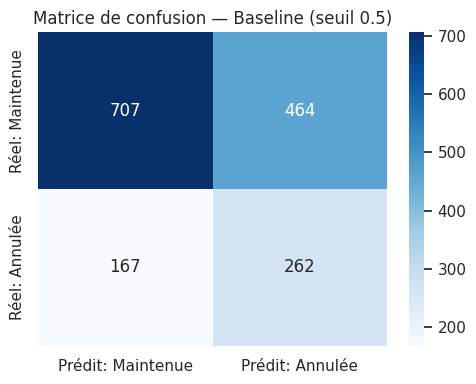

array([[707, 464],
       [167, 262]])

In [5]:
plot_confusion(y_val, val_pred_baseline, title="Matrice de confusion — Baseline (seuil 0.5)")

### 2.4 Effet du seuil de décision

`class_weight="balanced"` influence l'apprentissage mais le seuil de décision (0.5 par défaut) reste un
levier indépendant. On trace la courbe précision/rappel/F1 en fonction du seuil pour visualiser le
compromis, sans encore figer de choix définitif (approfondi au notebook 03 avec les modèles finaux).

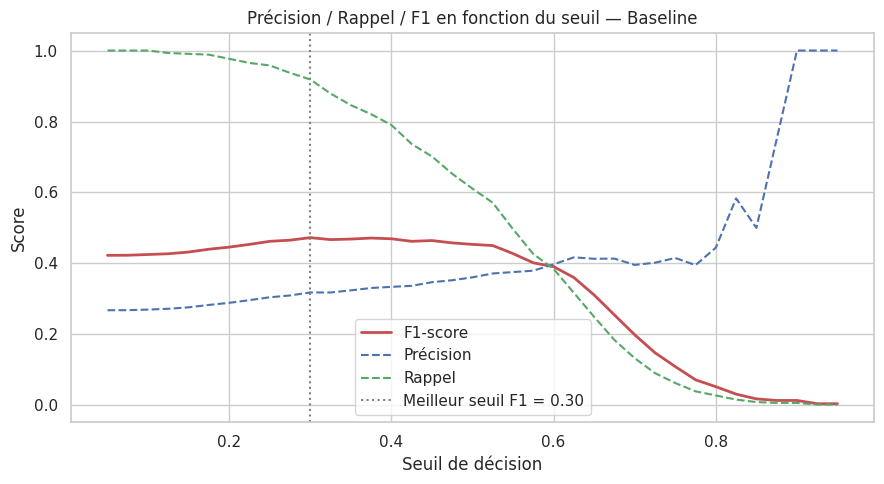

Meilleur F1 obtenu : 0.4727 au seuil 0.30 (vs 0.4537 au seuil 0.5)


In [6]:
thresholds, f1s, precisions, recalls = threshold_curve(y_val, val_proba_baseline)
best_t = plot_threshold_curve(thresholds, f1s, precisions, recalls, title="Précision / Rappel / F1 en fonction du seuil — Baseline")

print(f"Meilleur F1 obtenu : {f1s.max():.4f} au seuil {best_t:.2f} (vs {baseline_results['f1']:.4f} au seuil 0.5)")

### 2.5 Bilan de la baseline

La régression logistique établit un **score de référence** que les modèles suivants (notebook 03) devront
dépasser pour justifier leur complexité additionnelle. Ses coefficients sont directement interprétables
(voir l'analyse des coefficients au notebook 05), ce qui en fait aussi un outil de compréhension du
problème, indépendamment de sa performance brute.

Le score de référence à battre est résumé ci-dessous (reporté également dans le README).

In [7]:
pd.DataFrame([baseline_results])

,modele,seuil,f1,precision,recall,roc_auc
0,Régression logistique — baseline,0.5,0.45368,0.360882,0.610723,0.65323
